# 🫀 Cardiovascular Risk Model Training Walkthrough

This notebook is a **step-by-step training guide** for your hackathon team.

You will learn how to:
- load and inspect the dataset
- clean problematic records
- engineer meaningful health features
- train and compare models
- evaluate performance with visualizations
- produce risk scores and categories for product usage

> Hackathon constraints from project docs: train from scratch, no pretrained models, no external APIs.


## How to use this notebook

1. Run cells top-to-bottom.
2. Start with default settings.
3. Change only values in the **🔧 TWEAKABLE VARIABLES** cell.
4. Re-run from that cell downward after each tweak.

---

## Definitions (quick glossary)

- **Feature**: an input variable used by a model (e.g., blood pressure).
- **Target (`cardio`)**: what we predict (`0` = no disease, `1` = disease).
- **Outlier**: a value far outside realistic range (e.g., negative blood pressure).
- **Feature Engineering**: creating new useful inputs (e.g., BMI).
- **Train/Test Split**: train on one subset, evaluate on unseen subset.
- **Hyperparameter**: a model setting you tune (e.g., number of trees).
- **Threshold**: probability cutoff for converting score to class label.
- **Precision**: of predicted positives, how many are correct.
- **Recall**: of actual positives, how many we found.
- **F1**: balance between precision and recall.
- **ROC-AUC**: ranking quality across all thresholds (higher is better).


## Environment setup (run once in terminal)

```bash
python3 -m venv .venv
source .venv/bin/activate
pip install --upgrade pip
pip install pandas numpy scikit-learn matplotlib seaborn joblib jupyter
```

Dataset path used in this notebook: `data/cardio_train.csv`


In [1]:
%matplotlib inline

# Core Python and data science imports
import json
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:

# =========================================================
# 🔧 TWEAKABLE VARIABLES (team should edit only this cell)
# =========================================================

# Resolve project root robustly (works if notebook is run from repo root OR /training)
_PROJECT_ROOT = Path.cwd()
if not (_PROJECT_ROOT / "data" / "cardio_train.csv").exists():
    candidate = _PROJECT_ROOT.parent
    if (candidate / "data" / "cardio_train.csv").exists():
        _PROJECT_ROOT = candidate

# Data path
DATA_PATH = _PROJECT_ROOT / "data" / "cardio_train.csv"

# Reproducibility and split
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Model selection rule: choose the model with best score on this metric
SELECT_MODEL_BY = "f1"  # options: "f1", "accuracy", "roc_auc", "precision", "recall", "specificity", "fnr", "npv", "brier"

# Optional hard preference for deployment model
FORCE_MODEL_NAME = "gradient_boosting"  # set to None to use metric-based selection

# Classification / risk thresholds (recall-priority defaults from analysis)
CLASSIFICATION_THRESHOLD = 0.37
RISK_LOW_THRESHOLD = 0.313
RISK_HIGH_THRESHOLD = 0.625

# Data cleaning thresholds (physiologically plausible defaults)
MIN_HEIGHT_CM = 120
MAX_HEIGHT_CM = 220
MIN_WEIGHT_KG = 30
MAX_WEIGHT_KG = 250
MIN_AP_HI = 80
MAX_AP_HI = 250
MIN_AP_LO = 40
MAX_AP_LO = 160
REQUIRE_AP_HI_GE_AP_LO = True

# STRICT_CLEANING controls cleanup strategy:
# False => remove only invalid/impossible values (negative BP or bad BP order)
# True => also apply physiological range bounds
STRICT_CLEANING = True

# Feature toggles (lean defaults performed best in recent tests)
USE_BMI = False
USE_PULSE_PRESSURE = False
USE_LIFESTYLE_SCORE = False
USE_CHOL_GLUC_INTERACTION = False

# Logistic Regression hyperparameters
LR_C = 1.0
LR_MAX_ITER = 1500

# Random Forest hyperparameters
RF_N_ESTIMATORS = 500
RF_MAX_DEPTH = 12
RF_MIN_SAMPLES_SPLIT = 4
RF_MIN_SAMPLES_LEAF = 2

# Gradient Boosting hyperparameters
GB_N_ESTIMATORS = 100
GB_LEARNING_RATE = 0.10
GB_MAX_DEPTH = 3

# Reporting controls
SUBGROUP_MIN_COUNT = 120

# Artifact settings (timestamped files)
SAVE_ARTIFACTS = True
ARTIFACT_MODEL_PATH = _PROJECT_ROOT / "model.pkl"
ARTIFACT_METRICS_PATH = _PROJECT_ROOT / "metrics.json"

print("Tweakable settings loaded (recall-priority defaults).")
print(f"Resolved DATA_PATH: {DATA_PATH}")


Tweakable settings loaded (recall-priority defaults).
Resolved DATA_PATH: /home/nate/Projects/DataQuest26/data/cardio_train.csv


## 1) Load and inspect raw data

We start by checking shape, columns, and quick sample rows.

Note: raw Kaggle file in this project uses **semicolon delimiter** (`sep=';'`).


In [3]:
df_raw = pd.read_csv(DATA_PATH, sep=";")

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")
print("\nColumn names:")
print(df_raw.columns.tolist())

display(df_raw.head())


Rows: 70,000
Columns: 13

Column names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
# Data types + missing values overview
info_df = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)

display(info_df)

print("\nTarget distribution (cardio):")
display(df_raw["cardio"].value_counts().rename("count"))
display((df_raw["cardio"].value_counts(normalize=True) * 100).round(2).rename("percent"))


,dtype,missing_count,missing_pct
id,int64,0,0.0
age,int64,0,0.0
gender,int64,0,0.0
height,int64,0,0.0
weight,float64,0,0.0
ap_hi,int64,0,0.0
ap_lo,int64,0,0.0
cholesterol,int64,0,0.0
gluc,int64,0,0.0
smoke,int64,0,0.0



Target distribution (cardio):


cardio
0    35021
1    34979
Name: count, dtype: int64

cardio
0    50.03
1    49.97
Name: percent, dtype: float64

## 2) Exploratory Data Analysis (EDA)

EDA helps us understand patterns, class balance, and suspicious values before modeling.


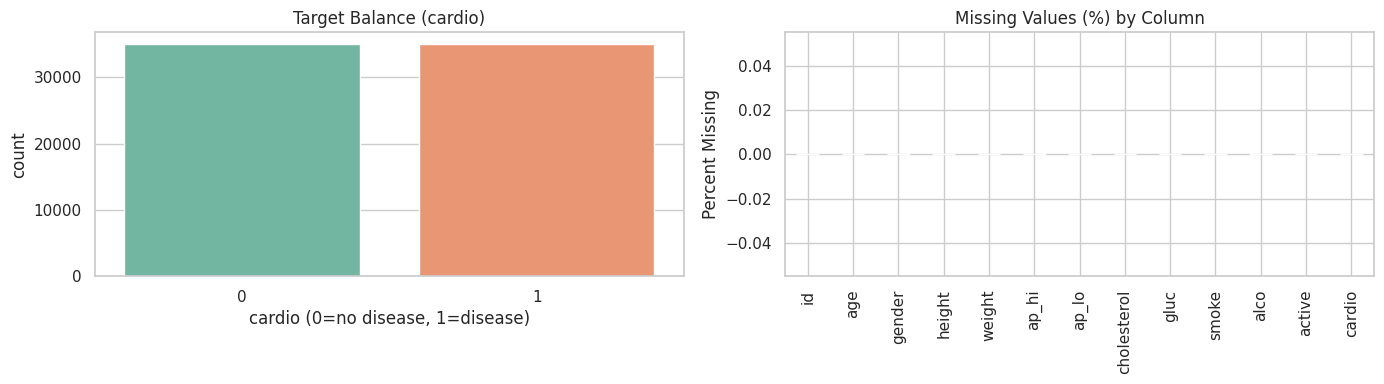

In [5]:
# Visualize target balance and missingness
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df_raw, x="cardio", ax=axes[0], palette="Set2")
axes[0].set_title("Target Balance (cardio)")
axes[0].set_xlabel("cardio (0=no disease, 1=disease)")

missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
missing_pct.plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].set_title("Missing Values (%) by Column")
axes[1].set_ylabel("Percent Missing")

plt.tight_layout()
plt.show()


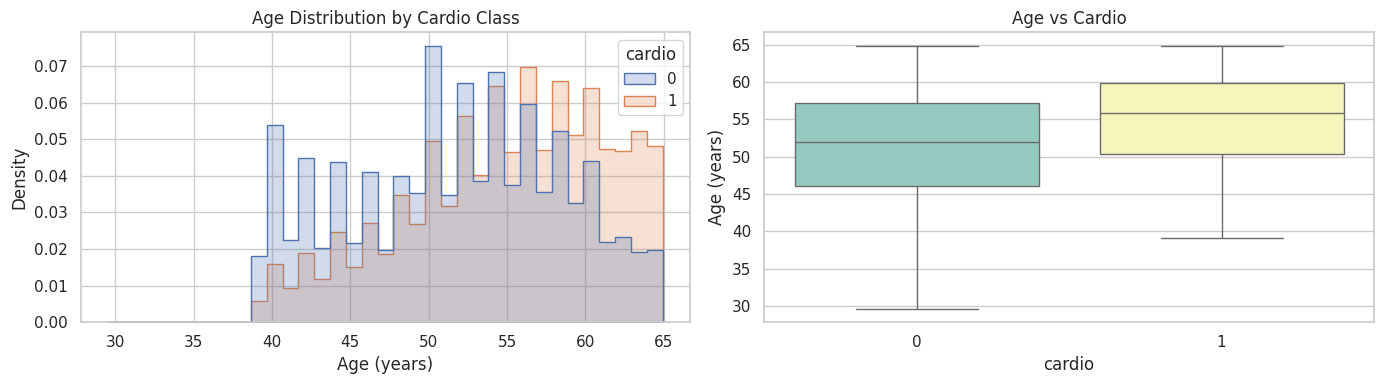

In [6]:
# Age is in DAYS in this dataset, so convert to YEARS for interpretation
df_eda = df_raw.copy()
df_eda["age_years"] = df_eda["age"] / 365.25

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(
    data=df_eda,
    x="age_years",
    hue="cardio",
    bins=35,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[0],
)
axes[0].set_title("Age Distribution by Cardio Class")
axes[0].set_xlabel("Age (years)")

sns.boxplot(data=df_eda, x="cardio", y="age_years", ax=axes[1], palette="Set3")
axes[1].set_title("Age vs Cardio")
axes[1].set_xlabel("cardio")
axes[1].set_ylabel("Age (years)")

plt.tight_layout()
plt.show()


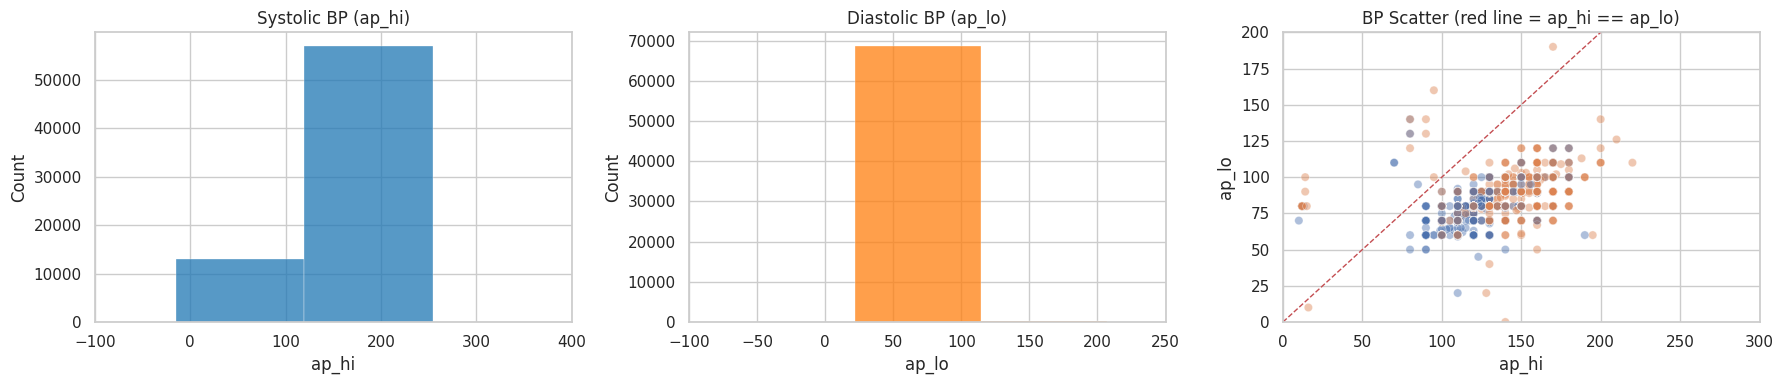

In [7]:
# Blood pressure sanity visuals (to detect impossible values)
sample_for_scatter = df_raw.sample(min(5000, len(df_raw)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df_raw["ap_hi"], bins=120, ax=axes[0], color="#1f77b4")
axes[0].set_title("Systolic BP (ap_hi)")
axes[0].set_xlim(-100, 400)

sns.histplot(df_raw["ap_lo"], bins=120, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Diastolic BP (ap_lo)")
axes[1].set_xlim(-100, 250)

sns.scatterplot(
    data=sample_for_scatter,
    x="ap_hi",
    y="ap_lo",
    hue="cardio",
    alpha=0.45,
    ax=axes[2],
    legend=False,
)
axes[2].plot([0, 300], [0, 300], "r--", linewidth=1)
axes[2].set_xlim(0, 300)
axes[2].set_ylim(0, 200)
axes[2].set_title("BP Scatter (red line = ap_hi == ap_lo)")

plt.tight_layout()
plt.show()


## 3) Clean the data

**Definition:** Data cleaning removes or fixes invalid values that can mislead a model.

Here we filter rows outside plausible ranges and optionally enforce `ap_hi >= ap_lo`.


In [8]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    # Remove invalid values and optionally apply stricter physiological bounds.
    df = df.copy()
    before = len(df)

    valid_mask = (df["ap_hi"] > 0) & (df["ap_lo"] > 0)

    if REQUIRE_AP_HI_GE_AP_LO:
        valid_mask &= df["ap_hi"] >= df["ap_lo"]

    cleaning_mode = "MINIMAL"
    if STRICT_CLEANING:
        cleaning_mode = "STRICT"
        valid_mask &= (
            df["height"].between(MIN_HEIGHT_CM, MAX_HEIGHT_CM)
            & df["weight"].between(MIN_WEIGHT_KG, MAX_WEIGHT_KG)
            & df["ap_hi"].between(MIN_AP_HI, MAX_AP_HI)
            & df["ap_lo"].between(MIN_AP_LO, MAX_AP_LO)
        )

    cleaned = df.loc[valid_mask].copy()
    after = len(cleaned)
    removed = before - after

    print(f"Cleaning mode       : {cleaning_mode}")
    print(f"Rows before cleaning: {before:,}")
    print(f"Rows after cleaning : {after:,}")
    print(f"Rows removed        : {removed:,} ({removed / before * 100:.2f}%)")

    return cleaned


In [9]:
df_clean = clean_data(df_raw)

# Compare class balance before vs after cleaning
balance_before = (df_raw["cardio"].value_counts(normalize=True) * 100).sort_index()
balance_after = (df_clean["cardio"].value_counts(normalize=True) * 100).sort_index()

comparison = pd.DataFrame({
    "before_cleaning_pct": balance_before,
    "after_cleaning_pct": balance_after,
}).round(2)

display(comparison)


Cleaning mode       : STRICT
Rows before cleaning: 70,000
Rows after cleaning : 68,610
Rows removed        : 1,390 (1.99%)


,before_cleaning_pct,after_cleaning_pct
cardio,,
0,50.03,50.53
1,49.97,49.47


## 4) Feature engineering

**Definition:** Feature engineering creates useful derived inputs from raw columns.

Added features:
- `age_years` = age in years
- `bmi` = weight / (height in meters)^2
- `pulse_pressure` = ap_hi - ap_lo
- `lifestyle_score` = active - smoke - alco
- `chol_gluc_interaction` = cholesterol * gluc


In [10]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    # Create derived health indicators used by the models.
    df = df.copy()

    # Age conversion: days -> years (improves interpretability)
    df["age_years"] = df["age"] / 365.25

    # Optional engineered features
    height_m = df["height"] / 100.0

    if USE_BMI:
        df["bmi"] = df["weight"] / (height_m ** 2)

    if USE_PULSE_PRESSURE:
        df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

    if USE_LIFESTYLE_SCORE:
        df["lifestyle_score"] = df["active"] - df["smoke"] - df["alco"]

    if USE_CHOL_GLUC_INTERACTION:
        df["chol_gluc_interaction"] = df["cholesterol"] * df["gluc"]

    return df


df_feat = engineer_features(df_clean)
preview_cols = [
    "age", "age_years", "height", "weight",
    "bmi", "pulse_pressure", "lifestyle_score", "chol_gluc_interaction"
]
preview_cols = [c for c in preview_cols if c in df_feat.columns]
display(df_feat[preview_cols].head())


,age,age_years,height,weight
0,18393,50.357290,168,62.0
1,20228,55.381246,156,85.0
2,18857,51.627652,165,64.0
3,17623,48.249144,169,82.0
4,17474,47.841205,156,56.0


In [11]:
# Visual check of engineered features vs target
plot_items = []

if "bmi" in df_feat.columns:
    plot_items.append(("box", "bmi", "BMI vs Cardio", "pastel"))

if "pulse_pressure" in df_feat.columns:
    plot_items.append(("box", "pulse_pressure", "Pulse Pressure vs Cardio", "muted"))

if "lifestyle_score" in df_feat.columns:
    plot_items.append(("count", "lifestyle_score", "Lifestyle Score Distribution by Cardio", "Set2"))

if plot_items:
    fig, axes = plt.subplots(1, len(plot_items), figsize=(6 * len(plot_items), 4))
    if len(plot_items) == 1:
        axes = [axes]

    for ax, (kind, col, title, palette) in zip(axes, plot_items):
        if kind == "box":
            sns.boxplot(data=df_feat, x="cardio", y=col, ax=ax, palette=palette)
        else:
            sns.countplot(data=df_feat, x=col, hue="cardio", ax=ax, palette=palette)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()
else:
    print("No optional engineered feature plots to show (all feature toggles are off).")


No optional engineered feature plots to show (all feature toggles are off).


## 5) Prepare training data

**Important concept:** avoid leakage.
- Do not include `cardio` (target) as an input.
- Do not duplicate age information (`age` in days + `age_years`).

We'll keep `age_years` and drop raw `age`.


In [12]:
TARGET_COL = "cardio"
DROP_COLS = ["id", "cardio", "age"]

X = df_feat.drop(columns=DROP_COLS)
y = df_feat[TARGET_COL]

categorical_features = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]
numeric_features = [c for c in X.columns if c not in categorical_features]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nCategorical features:", categorical_features)
print("\nNumeric features:", numeric_features)


Feature matrix shape: (68610, 11)
Target shape: (68610,)

Categorical features: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

Numeric features: ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train positive rate: {y_train.mean():.3f}")
print(f"y_test positive rate : {y_test.mean():.3f}")


X_train: (54888, 11) | X_test: (13722, 11)
y_train positive rate: 0.495
y_test positive rate : 0.495


## 6) Build preprocessing + train models

We compare:
- **Logistic Regression** (interpretable baseline)
- **Random Forest** (strong non-linear baseline)
- **Gradient Boosting** (top performer in our cross-validation sweep)

Pipeline ensures all preprocessing steps are learned on training data only.


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

model_defs = {
    "logistic_regression": LogisticRegression(
        C=LR_C,
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_split=RF_MIN_SAMPLES_SPLIT,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=GB_N_ESTIMATORS,
        learning_rate=GB_LEARNING_RATE,
        max_depth=GB_MAX_DEPTH,
        random_state=RANDOM_STATE,
    ),
}

trained_pipelines = {}
for name, model in model_defs.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"Trained: {name}")


Trained: logistic_regression


Trained: random_forest


Trained: gradient_boosting


## 7) Evaluate models

We compute core metrics plus medical-screening metrics:
- specificity
- false negative rate (FNR)
- negative predictive value (NPV)
- Brier score for probability quality

**Reminder:** threshold affects precision/recall tradeoff.


In [15]:

def evaluate_model(name: str, pipeline: Pipeline, X_eval: pd.DataFrame, y_eval: pd.Series, threshold: float):
    # Evaluate one model and return both metrics and raw predictions.
    probs = pipeline.predict_proba(X_eval)[:, 1]
    preds = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, preds).ravel()

    metrics = {
        "model": name,
        "accuracy": float(accuracy_score(y_eval, preds)),
        "precision": float(precision_score(y_eval, preds, zero_division=0)),
        "recall": float(recall_score(y_eval, preds, zero_division=0)),
        "f1": float(f1_score(y_eval, preds, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_eval, probs)),
        "specificity": float(tn / (tn + fp)),
        "fnr": float(fn / (fn + tp)),
        "npv": float(tn / (tn + fn)),
        "brier": float(brier_score_loss(y_eval, probs)),
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
        "classification_report": classification_report(y_eval, preds, output_dict=True, zero_division=0),
    }
    return metrics, preds, probs


evaluation_results = {}
pred_store = {}
prob_store = {}

for name, pipe in trained_pipelines.items():
    metrics, preds, probs = evaluate_model(name, pipe, X_test, y_test, CLASSIFICATION_THRESHOLD)
    evaluation_results[name] = metrics
    pred_store[name] = preds
    prob_store[name] = probs

metric_cols = [
    "accuracy", "precision", "recall", "f1", "roc_auc",
    "specificity", "fnr", "npv", "brier"
]

lower_is_better = {"fnr", "brier"}
sort_ascending = SELECT_MODEL_BY in lower_is_better

metrics_df = pd.DataFrame(evaluation_results).T[metric_cols].sort_values(
    by=SELECT_MODEL_BY,
    ascending=sort_ascending,
)

display(metrics_df.style.format("{:.4f}"))

if FORCE_MODEL_NAME and FORCE_MODEL_NAME in trained_pipelines:
    best_model_name = FORCE_MODEL_NAME
    print(f"Model override active: using '{best_model_name}'")
else:
    best_model_name = metrics_df.index[0]

best_pipeline = trained_pipelines[best_model_name]

print(f"Evaluation threshold: {CLASSIFICATION_THRESHOLD:.2f}")
print(f"Best model by '{SELECT_MODEL_BY}': {best_model_name}")


,accuracy,precision,recall,f1,roc_auc,specificity,fnr,npv,brier
gradient_boosting,0.7138,0.6743,0.8154,0.7382,0.8022,0.6143,0.1846,0.7727,0.1803
random_forest,0.7082,0.6660,0.8229,0.7362,0.8017,0.5958,0.1771,0.7746,0.1805
logistic_regression,0.6944,0.6470,0.8417,0.7316,0.7933,0.5503,0.1583,0.7802,0.1858


Model override active: using 'gradient_boosting'
Evaluation threshold: 0.37
Best model by 'f1': gradient_boosting


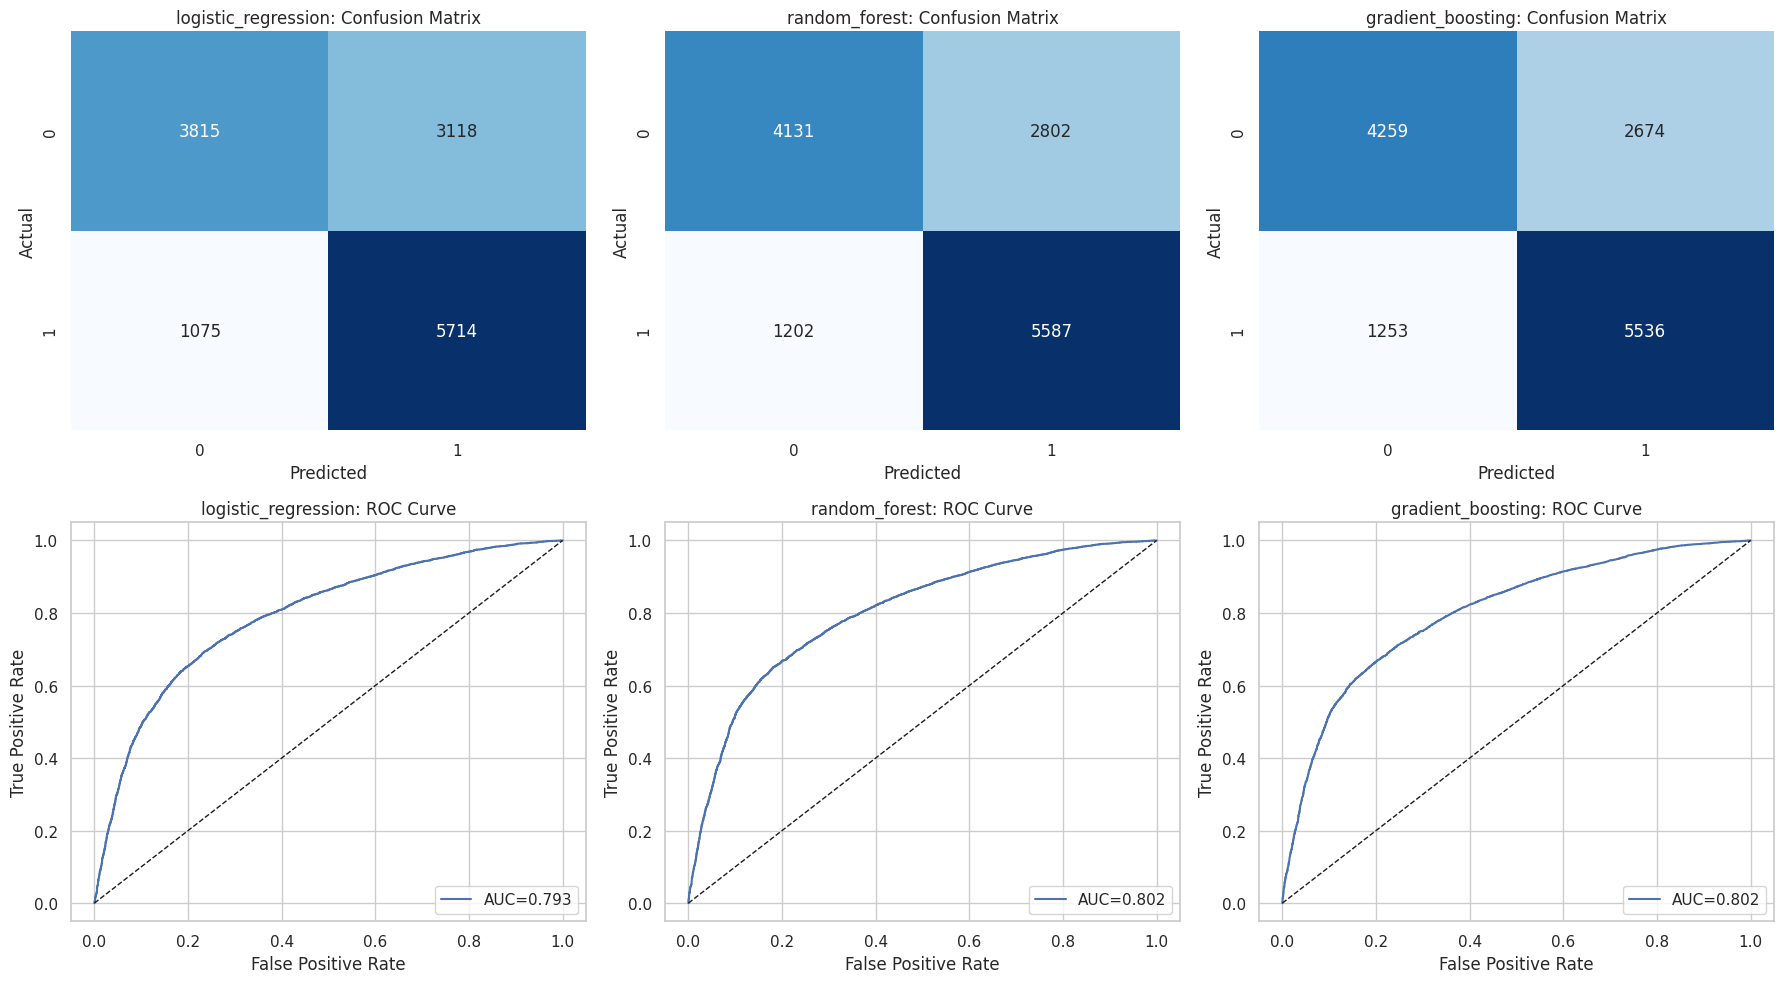

In [16]:
# Confusion matrix + ROC per model
model_names = list(trained_pipelines.keys())
n_models = len(model_names)

fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10))
axes = np.array(axes).reshape(2, n_models)

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, pred_store[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, i])
    axes[0, i].set_title(f"{name}: Confusion Matrix")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("Actual")

    fpr, tpr, _ = roc_curve(y_test, prob_store[name])
    auc = roc_auc_score(y_test, prob_store[name])
    axes[1, i].plot(fpr, tpr, label=f"AUC={auc:.3f}")
    axes[1, i].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[1, i].set_title(f"{name}: ROC Curve")
    axes[1, i].set_xlabel("False Positive Rate")
    axes[1, i].set_ylabel("True Positive Rate")
    axes[1, i].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 8) Interpret the best model

For Random Forest, we use feature importance.
For Logistic Regression, we inspect absolute coefficients.


,feature,feature_importance
2,num__ap_hi,0.744851
4,num__age_years,0.132051
9,cat__cholesterol_3,0.055864
7,cat__cholesterol_1,0.018764
1,num__weight,0.018285
3,num__ap_lo,0.011535
18,cat__active_1,0.003844
12,cat__gluc_3,0.003385
0,num__height,0.002330
17,cat__active_0,0.002094


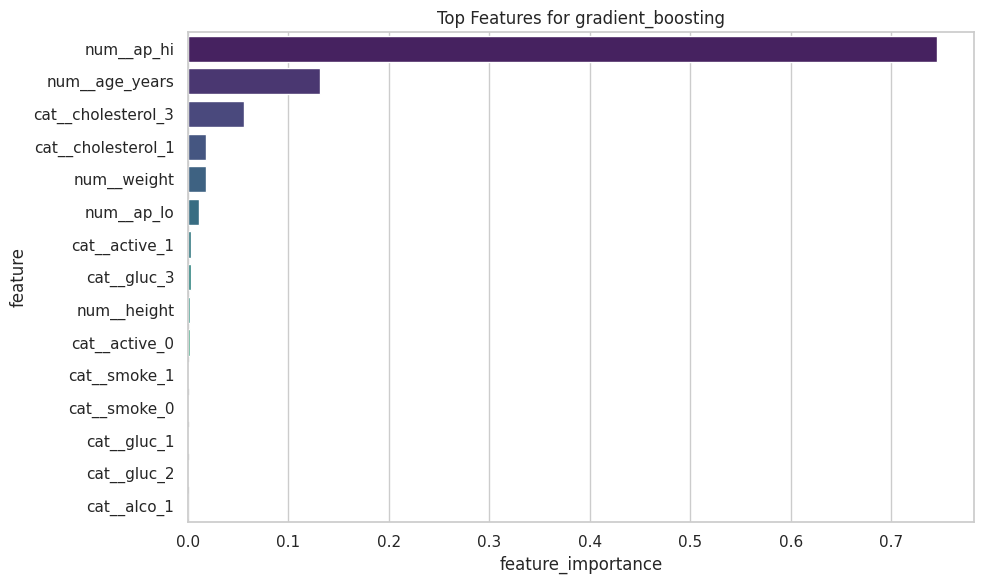

In [17]:
pre = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["model"]
transformed_feature_names = pre.get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
    importance_label = "feature_importance"
elif hasattr(model, "coef_"):
    # For linear models, use absolute coefficient magnitude.
    importance_values = np.abs(model.coef_[0])
    importance_label = "abs_coefficient"
else:
    importance_values = None
    importance_label = "importance"

if importance_values is not None:
    importance_df = (
        pd.DataFrame({"feature": transformed_feature_names, importance_label: importance_values})
        .sort_values(importance_label, ascending=False)
        .head(15)
    )

    display(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x=importance_label, y="feature", palette="viridis")
    plt.title(f"Top Features for {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"Model '{best_model_name}' does not expose direct feature importance values.")


## 9) Convert probabilities into risk categories + subgroup checks

Product-oriented output for each patient:
- prediction (0/1)
- risk probability (0-1)
- risk score (0-100%)
- risk category (Low/Medium/High)

We also summarize subgroup performance so the team can spot where recall is weakest.


In [18]:

def risk_category(prob: float) -> str:
    if prob < RISK_LOW_THRESHOLD:
        return "Low"
    if prob <= RISK_HIGH_THRESHOLD:
        return "Medium"
    return "High"


def compute_binary_metrics(y_true: pd.Series, y_pred: np.ndarray):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "specificity": float(tn / (tn + fp)),
        "fnr": float(fn / (fn + tp)),
    }


scored = X_test.copy()
scored["true_label"] = y_test.values
scored["risk_probability"] = prob_store[best_model_name]
scored["risk_score_pct"] = (scored["risk_probability"] * 100).round(2)
scored["predicted_label"] = (scored["risk_probability"] >= CLASSIFICATION_THRESHOLD).astype(int)
scored["risk_category"] = scored["risk_probability"].apply(risk_category)

display(scored[["risk_probability", "risk_score_pct", "risk_category", "predicted_label", "true_label"]].head(10))

print("\nRisk category counts:")
display(scored["risk_category"].value_counts())

risk_band_quality = (
    scored.groupby("risk_category", as_index=False)
    .agg(
        n=("true_label", "size"),
        observed_positive_rate=("true_label", "mean"),
        avg_predicted_risk=("risk_probability", "mean"),
    )
    .sort_values("avg_predicted_risk")
)

print("\nRisk band quality check:")
display(risk_band_quality)

# Quick threshold sensitivity for the chosen model
threshold_rows = []
for t in np.arange(0.30, 0.56, 0.05):
    t = float(round(t, 2))
    preds_t = (scored["risk_probability"].values >= t).astype(int)
    row = {"threshold": t}
    row.update(compute_binary_metrics(y_test, preds_t))
    threshold_rows.append(row)

threshold_sensitivity_df = pd.DataFrame(threshold_rows)
print("\nThreshold sensitivity (chosen model):")
display(threshold_sensitivity_df.style.format("{:.4f}"))

# Subgroup performance summary for fairness/robustness checks
subgroup_tables = {}

if "age_years" in scored.columns:
    scored["age_bin"] = pd.qcut(scored["age_years"], q=4, duplicates="drop")

group_cols = [
    c for c in ["age_bin", "gender", "cholesterol", "gluc", "active", "smoke", "alco"]
    if c in scored.columns
]

for col in group_cols:
    rows = []
    for group_value, part in scored.groupby(col):
        n = len(part)
        if n < SUBGROUP_MIN_COUNT:
            continue
        metrics = compute_binary_metrics(part["true_label"], part["predicted_label"].values)
        rows.append({
            "group": str(group_value),
            "n": int(n),
            "prevalence": float(part["true_label"].mean()),
            **metrics,
        })

    subgroup_df = pd.DataFrame(rows).sort_values("recall") if rows else pd.DataFrame()
    subgroup_tables[col] = subgroup_df

print("\nSubgroup recall summary (lowest recall first):")
for col, subgroup_df in subgroup_tables.items():
    if subgroup_df.empty:
        continue
    print(f"\n[{col}]")
    display(subgroup_df)

# Export-friendly objects for metrics JSON
threshold_sensitivity_table_export = threshold_sensitivity_df.to_dict(orient="records")
subgroup_summary_export = {
    col: df.to_dict(orient="records")
    for col, df in subgroup_tables.items()
}
risk_band_quality_export = risk_band_quality.to_dict(orient="records")


,risk_probability,risk_score_pct,risk_category,predicted_label,true_label
19499,0.841281,84.13,High,1,1
25553,0.734327,73.43,High,1,1
31418,0.270109,27.01,Low,0,0
62742,0.522994,52.30,Medium,1,0
16400,0.513524,51.35,Medium,1,1
41426,0.546010,54.60,Medium,1,1
41140,0.556208,55.62,Medium,1,1
2003,0.854734,85.47,High,1,1
43614,0.381895,38.19,Medium,1,0
15863,0.284840,28.48,Low,0,0



Risk category counts:


risk_category
Medium    4642
High      4639
Low       4441
Name: count, dtype: int64


Risk band quality check:


,risk_category,n,observed_positive_rate,avg_predicted_risk
1,Low,4441,0.203107,0.209689
2,Medium,4642,0.449375,0.453492
0,High,4639,0.819358,0.809852


...

,group,n,prevalence,precision,recall,f1,specificity,fnr
1,1,11048,0.483979,0.675935,0.804750,0.734739,0.638134,0.195250
0,0,2674,0.539267,0.668655,0.855062,0.750456,0.504058,0.144938



[smoke]


,group,n,prevalence,precision,recall,f1,specificity,fnr
1,1,1245,0.470683,0.687591,0.803754,0.741149,0.675266,0.196246
0,0,12477,0.497155,0.673090,0.816540,0.737908,0.607906,0.183460



[alco]


,group,n,prevalence,precision,recall,f1,specificity,fnr
0,0,12964,0.496066,0.672926,0.813559,0.736590,0.610745,0.186441
1,1,758,0.472296,0.698851,0.849162,0.766709,0.672500,0.150838


In [19]:

# Optional: save artifacts for backend usage
if SAVE_ARTIFACTS:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    model_path = ARTIFACT_MODEL_PATH.with_name(
        f"{ARTIFACT_MODEL_PATH.stem}_{run_timestamp}{ARTIFACT_MODEL_PATH.suffix}"
    )
    metrics_path = ARTIFACT_METRICS_PATH.with_name(
        f"{ARTIFACT_METRICS_PATH.stem}_{run_timestamp}{ARTIFACT_METRICS_PATH.suffix}"
    )
    clean_data_path = DATA_PATH.parent / f"cardio_clean_{run_timestamp}.csv"

    joblib.dump(best_pipeline, model_path)
    df_clean.to_csv(clean_data_path, index=False)

    serializable_metrics = {
        k: {
            kk: vv
            for kk, vv in v.items()
            if kk in {
                "model", "accuracy", "precision", "recall", "f1", "roc_auc",
                "specificity", "fnr", "npv", "brier", "confusion_matrix"
            }
        }
        for k, v in evaluation_results.items()
    }

    serializable_metrics["run_config"] = {
        "selected_model": best_model_name,
        "selection_metric": SELECT_MODEL_BY,
        "force_model_name": FORCE_MODEL_NAME,
        "classification_threshold": CLASSIFICATION_THRESHOLD,
        "risk_low_threshold": RISK_LOW_THRESHOLD,
        "risk_high_threshold": RISK_HIGH_THRESHOLD,
        "strict_cleaning": STRICT_CLEANING,
        "use_bmi": USE_BMI,
        "use_pulse_pressure": USE_PULSE_PRESSURE,
        "use_lifestyle_score": USE_LIFESTYLE_SCORE,
        "use_chol_gluc_interaction": USE_CHOL_GLUC_INTERACTION,
    }

    serializable_metrics["risk_band_quality"] = risk_band_quality_export
    serializable_metrics["threshold_sensitivity"] = threshold_sensitivity_table_export
    serializable_metrics["subgroup_performance"] = subgroup_summary_export

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(serializable_metrics, f, indent=2)

    print(f"Saved model to: {model_path}")
    print(f"Saved metrics to: {metrics_path}")
    print(f"Saved cleaned data to: {clean_data_path}")
else:
    print("SAVE_ARTIFACTS is False, so no files were written.")


Saved model to: /home/nate/Projects/DataQuest26/model_20260321_143404.pkl
Saved metrics to: /home/nate/Projects/DataQuest26/metrics_20260321_143404.json
Saved cleaned data to: /home/nate/Projects/DataQuest26/data/cardio_clean_20260321_143404.csv


## 10) Team experiments (recommended)

Try these one at a time and compare results:
1. Change `CLASSIFICATION_THRESHOLD` (0.30, 0.37, 0.45, 0.50).
2. Toggle engineered features (`USE_BMI`, `USE_PULSE_PRESSURE`, `USE_LIFESTYLE_SCORE`, `USE_CHOL_GLUC_INTERACTION`).
3. Switch strict/minimal cleaning with `STRICT_CLEANING`.
4. Change model ranking metric with `SELECT_MODEL_BY` (`f1` or `recall` for screening).
5. Set `FORCE_MODEL_NAME = None` to compare pure metric selection vs forced `gradient_boosting`.
6. Review subgroup tables and target the weakest-recall group with additional feature ideas.
7. Tune `RF_*` and `GB_*` hyperparameters and compare ROC-AUC + FNR.

Record each experiment in a simple table for your hackathon presentation.
